In [1]:
import pandas as pd

hydrazide_df = pd.read_csv("../data/hydrazide_library.csv")
len(hydrazide_df)

10000

In [2]:
'''removing invalid smiles from the source'''

from rdkit import Chem

hydrazide_df["mol"] = hydrazide_df["SMILES"].apply(Chem.MolFromSmiles)

invalid_count = hydrazide_df["mol"].isna().sum()
print(f"Invalid SMILES: {invalid_count}")

invalid_smiles = hydrazide_df[hydrazide_df["mol"].isna()]
display(invalid_smiles[["Name", "SMILES"]])

hydrazide_df = hydrazide_df[
    hydrazide_df["mol"].notna()
].reset_index(drop=True)

len(hydrazide_df)

[20:19:53] Explicit valence for atom # 11 Br, 3, is greater than permitted
[20:19:53] Explicit valence for atom # 11 Cl, 3, is greater than permitted
[20:19:53] Explicit valence for atom # 8 Br, 3, is greater than permitted
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] Explicit valence for atom # 176 Cl, 2, is greater than permitted
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] Explicit valence for atom # 95 Cl, 2, is greater than permitted
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydroge

Invalid SMILES: 11


[20:19:54] Explicit valence for atom # 1 Br, 3, is greater than permitted
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors
[20:19:54] WARNING: not removing hydrogen atom without neighbors


,Name,SMILES
7700,5-[1-(3-Chloro-2-pyridinyl)-3-(trifluoromethyl...,C1=CC=C2C(=C1)C=C(C3=C2OBr=C(N3)C4=CC(=NN4C5=C...
7701,5-[1-(3-Chloro-2-pyridinyl)-3-(trifluoromethyl...,C1=CC=C2C(=C1)C=C(C3=C2OCl=C(N3)C4=CC(=NN4C5=C...
7702,4-[1-(3-Chloro-2-pyridinyl)-3-(trifluoromethyl...,CC1=CC(=C2C(=C1)OBr=C(N2)C3=CC(=NN3C4=C(C=CC=N...
8340,CID 157315559,[HH].B(Br)(Br)Br.CCO.CC#N.CC1=CN=C(C=C1)Br.CC1...
8405,2-(4-aminochloranuidylpiperidin-1-yl)-5-(4-chl...,CC1CCNCC1.CC1CCN(CC1)C2=NN=C(O2)C3=CC=C(C=C3)C...
8490,sodium;tert-butyl 2-bromoacetate;4-O-tert-buty...,[HH].[H-].[2H]CF.C.C.[CH3-].CCNC(=O)CCCC(C)C.C...
8525,"lithium;[1-[1-[2,4-bis(trifluoromethyl)phenyl]...",[Li+].CCOC(=O)C1=NN=C(O1)C2=CC=CC=N2.CCOC(=O)C...
8661,"benzoic acid;3-(5-butyl-1,3,4-oxadiazol-2-yl)-...",CCCCC1=NN=C(O1)C2=CC(=CC=C2)S(=O)(=O)NC3=CC=CC...
8810,"1-aminochloranuidyl-1-methoxy-2,2-dimethylprop...",C.CCC(=O)CC(C)(C)C.CC1=CC=C(C=C1)C(C)(C)C.CC(C...
8870,"lithium;[1-[1-[2,4-bis(trifluoromethyl)phenyl]...",[Li+].C.C.C.C.C.C.C.C.C.C.CCOC(=O)C1=NN=C(O1)C...


9989

In [3]:
'''making sure all molecules have valid hydrazide moeity'''

hydrazide_pattern = Chem.MolFromSmarts("[CX3](=O)[NH][NH2]")

true_hydrazide_df = hydrazide_df[
    hydrazide_df["mol"].apply(
        lambda mol: mol.HasSubstructMatch(hydrazide_pattern)
    )
].reset_index(drop=True)

len(true_hydrazide_df)

9938

In [4]:
'''removing salts from the library'''

neutral_hydrazide_df = true_hydrazide_df[
    true_hydrazide_df["mol"].apply(
        lambda mol: Chem.GetFormalCharge(mol) == 0
    )
].reset_index(drop=True)

len(neutral_hydrazide_df)

9818

In [5]:
'''calculating no. of aromatic rings present in the molecule'''

from rdkit.Chem import rdMolDescriptors

neutral_hydrazide_df["Aromatic_Ring_Count"] = hydrazide_df["mol"].apply(
    rdMolDescriptors.CalcNumAromaticRings
)

In [6]:
'''Applying Lipinski's rule'''

filtered_hydrazide_df = neutral_hydrazide_df[
    (neutral_hydrazide_df["Molecular_Weight"] < 500) &
    (neutral_hydrazide_df["XLogP"] < 5) &
    (neutral_hydrazide_df["Polar_Area"] < 140) &
    (neutral_hydrazide_df["Rotatable_Bond_Count"] < 10) &
    (neutral_hydrazide_df["Aromatic_Ring_Count"] >= 1)
].reset_index(drop=True)

len(filtered_hydrazide_df)

6414

In [7]:
'''catagorizing molecules based on the func. groups, heterocycles, halogens'''

functional_groups = {
    # Nitrogen heterocycles
    "Pyridine": Chem.MolFromSmarts("n1ccccc1"),
    "Pyrrole": Chem.MolFromSmarts("[nH]1cccc1"),
    "Imidazole": Chem.MolFromSmarts("c1ncc[nH]1"),
    "Pyrazole": Chem.MolFromSmarts("c1n[nH]cc1"),
    "1,2,3-Triazole": Chem.MolFromSmarts("n1nncc1"),
    "1,2,4-Triazole": Chem.MolFromSmarts("n1ncnc1"),
    "1,2,3,4-Tetrazole": Chem.MolFromSmarts("c1nnnn1"),
    "1-H-Tetrazole": Chem.MolFromSmarts("[nH]1nnnc1"),
    "Quinoline": Chem.MolFromSmarts("c1ccc2ncccc2c1"),
    "Isoquinoline": Chem.MolFromSmarts("c1ccc2ccnc2c1"),

    # Oxygen/Sulfur heterocycles
    "Thiophene": Chem.MolFromSmarts("c1ccsc1"),
    "Furan": Chem.MolFromSmarts("c1ccoc1"),
    "Benzofuran": Chem.MolFromSmarts("c1ccc2occc2c1"),

    # Functional groups
    "Phenol": Chem.MolFromSmarts("c[OH]"),
    "Methoxy": Chem.MolFromSmarts("[OX2][CH3]"),
    "Nitro": Chem.MolFromSmarts("[N+](=O)[O-]"),
    "Cyano": Chem.MolFromSmarts("C#N"),

    # Halogens
    "Fluoro": Chem.MolFromSmarts("[F]"),
    "Chloro": Chem.MolFromSmarts("[Cl]"),
    "Bromo": Chem.MolFromSmarts("[Br]"),
    "Iodo": Chem.MolFromSmarts("[I]"),

    # Carbonyl derivatives
    "Carboxylic_Acid": Chem.MolFromSmarts("C(=O)[OH]"),
    "Ester": Chem.MolFromSmarts("C(=O)O[#6]"),
    "Aldehyde": Chem.MolFromSmarts("[CX3H](=O)"),
    "Ketone": Chem.MolFromSmarts("[#6][CX3](=O)[#6]"),

    # Sulfur groups
    "Sulfone": Chem.MolFromSmarts("S(=O)(=O)"),
    "Sulfonamide": Chem.MolFromSmarts("S(=O)(=O)N"),
    "Trifluoromethyl": Chem.MolFromSmarts("C(F)(F)F")
}

for name, pattern in functional_groups.items():
    filtered_hydrazide_df[name] = filtered_hydrazide_df["mol"].apply(
        lambda mol: mol.HasSubstructMatch(pattern)
    )

fg_counts = filtered_hydrazide_df[
    functional_groups.keys()
].sum().sort_values(ascending=False)

display(fg_counts)

Fluoro               3721
Trifluoromethyl      1300
Pyridine             1272
Chloro               1019
Methoxy               527
Sulfone               353
Quinoline             285
Isoquinoline          268
Ester                 260
Bromo                 256
Sulfonamide           241
Phenol                193
Thiophene             181
Pyrrole               171
Ketone                161
Furan                 146
Carboxylic_Acid       124
1,2,4-Triazole        115
Cyano                 115
Nitro                 101
Pyrazole               94
Imidazole              68
Iodo                   57
1,2,3-Triazole         45
Aldehyde               32
Benzofuran             31
1,2,3,4-Tetrazole      30
1-H-Tetrazole           0
dtype: int64

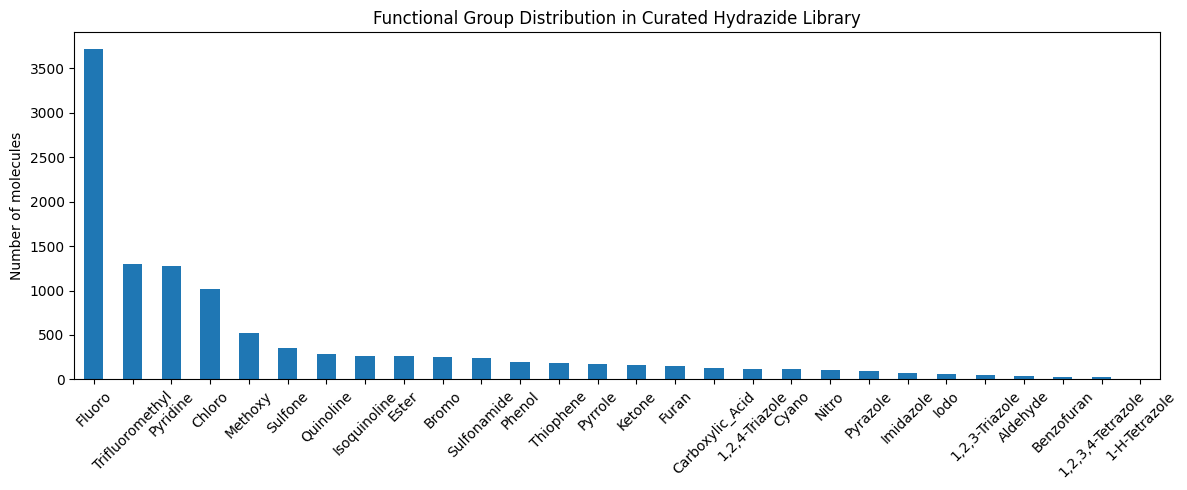

In [8]:
'''visualising the func. group distribution in our library'''

import matplotlib.pyplot as plt

fg_counts.plot.bar(figsize=(12,5))

plt.ylabel("Number of molecules")
plt.title("Functional Group Distribution in Curated Hydrazide Library")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [9]:
'''identifying hydrazide counts'''

hydrazide = Chem.MolFromSmarts("[CX3](=O)[NH][NH2]")
filtered_hydrazide_df["Hydrazide_Count"] = filtered_hydrazide_df["mol"].apply(
    lambda m: len(m.GetSubstructMatches(hydrazide))
)

filtered_hydrazide_df["Hydrazide_Count"].value_counts().sort_index()

Hydrazide_Count
1    6327
2      87
Name: count, dtype: int64

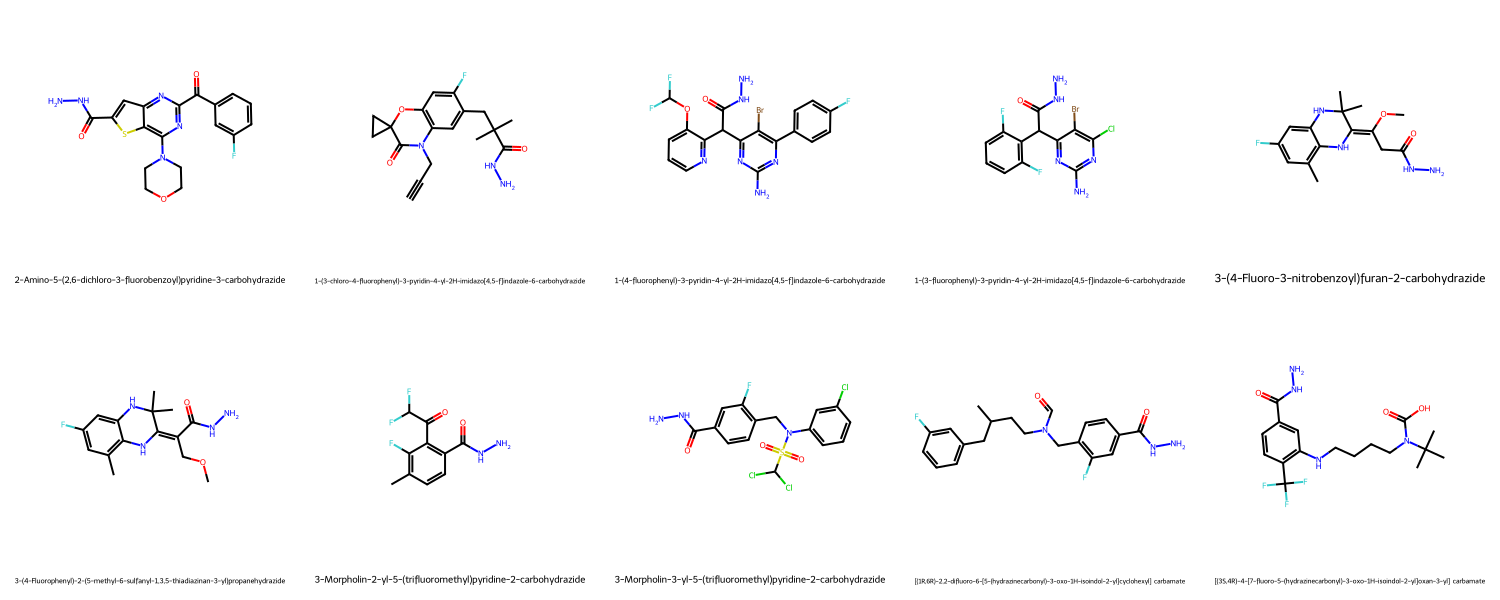

In [10]:
from rdkit.Chem import Draw

mols_2 = filtered_hydrazide_df[
    filtered_hydrazide_df["Hydrazide_Count"] == 1
]["mol"].tail(10).tolist()

legends_2 = filtered_hydrazide_df[
    filtered_hydrazide_df["Hydrazide_Count"] == 1
]["Name"].astype(str).tail(21).tolist()

Draw.MolsToGridImage(
    mols_2,
    legends=legends_2,
    molsPerRow=5,
    subImgSize=(300,300)
)

In [11]:
'''Identifying Aromaticity of the molecules'''

def has_aromatic_ring(mol):
    return any(atom.GetIsAromatic() for atom in mol.GetAtoms())

filtered_hydrazide_df["Aromatic"] = filtered_hydrazide_df["mol"].apply(has_aromatic_ring)

filtered_hydrazide_df["Aromatic"].value_counts()

Aromatic
True     5941
False     473
Name: count, dtype: int64

In [12]:
'''Removing aliphatic molecules from the library'''

def has_aromatic_ring(mol):
    ring_info = mol.GetRingInfo()
    for ring in ring_info.AtomRings():
        if all(mol.GetAtomWithIdx(i).GetIsAromatic() for i in ring):
            return True
    return False

filtered_hydrazide_df = filtered_hydrazide_df[
    filtered_hydrazide_df["mol"].apply(has_aromatic_ring)
].copy()

len(filtered_hydrazide_df)

5941

In [13]:
filtered_hydrazide_df.to_csv(
    "../results/clean_hydrazides.csv",
    index=False
)